In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from glob import glob
from tqdm import tqdm

# --- 1. VERİYİ İNDİR ---
if not os.path.exists('GTSRB_Final_Training_Images.zip'):
    print("Veri indiriliyor...")
    !wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
    !unzip -q GTSRB_Final_Training_Images.zip
else:
    print("Veri zaten inmiş durumda.")

data_dir = './GTSRB/Final_Training/Images'

# --- 2. FORMAT DÖNÜŞÜMÜ (.ppm -> .jpg) ---
# Sadece .ppm dosyaları varsa dönüştür, yoksa geç
files = glob(f"{data_dir}/*/*.ppm")
if len(files) > 0:
    print(f"{len(files)} adet resim .jpg formatına dönüştürülüyor...")
    for file in tqdm(files):
        img = cv2.imread(file)
        if img is not None:
            new_filename = file.replace(".ppm", ".jpg")
            cv2.imwrite(new_filename, img)
            os.remove(file)
    print("Dönüştürme tamamlandı.")
else:
    print("Resimler zaten dönüştürülmüş veya .ppm dosyası yok.")

# --- 3. VERİ SETİ OLUŞTURMA (PERFORMANS AYARLI) ---
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

print("Veri setleri yükleniyor...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Performans için cache ve prefetch (Eğitimi hızlandırır)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Veri hazırlığı tamam!")

Veri indiriliyor...
39209 adet resim .jpg formatına dönüştürülüyor...


100%|██████████| 39209/39209 [00:05<00:00, 7290.04it/s]


Dönüştürme tamamlandı.
Veri setleri yükleniyor...
Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.
✅ Veri hazırlığı tamam!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 8,803,563 (33.58 MB)

 Trainable params: 8,801,579 (33.58 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.5923 - loss: 1.4678 - val_accuracy: 0.9114 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.8716 - loss: 0.4274 - val_accuracy: 0.9074 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9213 - loss: 0.2643 - val_accuracy: 0.9747 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9519 - loss: 0.1584 - val_accuracy: 0.9827 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9445 - loss: 0.1875 - val_accuracy: 0.9783 - val_loss: 0.0738 - learning_rate: 0.0010
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9439 - loss: 0.1822 - val_accuracy: 0.9283 - val_loss: 0.2566 - learning_rate: 0.0010
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.9568 - l

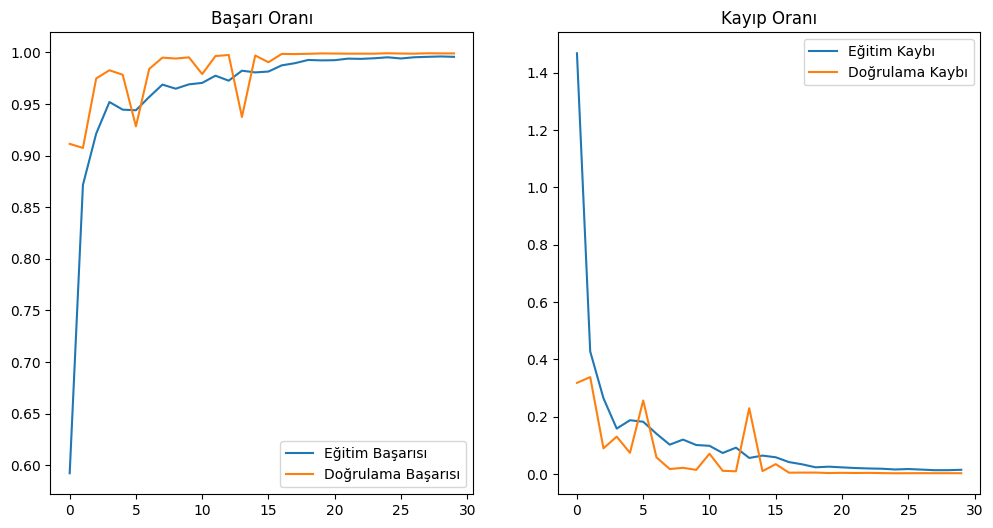

In [2]:
# --- 4. MODEL MİMARİSİ ---

# Data Augmentation (DÜZELTİLDİ: Flip kaldırıldı, Kontrast eklendi)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),       # Hafif döndürme
    layers.RandomZoom(0.1),           # Hafif yakınlaştırma
    layers.RandomContrast(0.1),       # Kontrast değişimi
    layers.RandomBrightness(0.1)      # Işık değişimi
])

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # 1. Blok
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(), # <-- Eklendi: Öğrenmeyi stabilize eder
    layers.MaxPooling2D((2, 2)),

    # 2. Blok
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(), # <-- Eklendi
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),         # <-- Eklendi: Ezberlemeyi önler

    # 3. Blok
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(), # <-- Eklendi
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # 4. Blok (Daha derin özellikler için)
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Sınıflandırma Katmanı
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5), # Yüksek dropout (ezberlemeyi engeller)
    layers.Dense(num_classes, activation='softmax')
])

# Modeli Derle
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

# --- 5. CALLBACKS (AKILLI EĞİTİM KONTROLLERİ) ---
# Bu kısım başarıyı en çok artıran yerdir.

my_callbacks = [
    # Eğer val_loss 3 epoch boyunca düşmezse öğrenme hızını azalt (ince ayar yap)
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1),

    # Eğer 6 epoch boyunca gelişme olmazsa eğitimi durdur (vakit kaybını önle)
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

# --- 6. EĞİTİMİ BAŞLAT ---
epochs = 30 # EarlyStopping olduğu için yüksek verebiliriz, gerekirse erken durur.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=my_callbacks
)

# --- GRAFİKLER ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
real_epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Eğitim Başarısı')
plt.plot(real_epochs, val_acc, label='Doğrulama Başarısı')
plt.title('Başarı Oranı')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Eğitim Kaybı')
plt.plot(real_epochs, val_loss, label='Doğrulama Kaybı')
plt.title('Kayıp Oranı')
plt.legend()
plt.show()

In [7]:
import gradio as gr
import base64
import os
import numpy as np
from PIL import Image

# --- 1. CLASS NAMES (English) ---
# GTSRB veri setinin standart İngilizce karşılıklarıdır.
classes = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing for vehicles over 3.5 metric tons',
    11: 'Right-of-way at the next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Vehicles over 3.5 metric tons prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End of all speed and passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End of no passing by vehicles over 3.5 metric tons'
}

# --- 2. PREDICTION FUNCTION ---
def predict_sign(image):
    if image is None: return None
    # Resize image to model input size (128x128)
    image = Image.fromarray(image).resize((128, 128))
    img_array = np.array(image)
    img_array = np.expand_dims(img_array, axis=0)

    # Assuming model is loaded in memory
    prediction = model.predict(img_array)[0]

    # Return results as dictionary
    return {classes[i]: float(prediction[i]) for i in range(len(classes))}

# --- 3. LOCAL LOGO LOADER ---
def get_local_logo(filename):
    if os.path.exists(filename):
        with open(filename, "rb") as image_file:
            encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
            print(f"✅ '{filename}' successfully loaded.")
            return f"data:image/png;base64,{encoded_string}"
    else:
        print(f"⚠️ ERROR: '{filename}' not found! Did you upload it to the file section?")
        # Fallback icon
        return "https://cdn-icons-png.flaticon.com/512/2997/2997287.png"

# File name (Must match the file uploaded to Colab)
logo_filename = "logo.png"
logo_data = get_local_logo(logo_filename)

# --- 4. HTML DESIGN (English Header & Footer) ---
header_html = f"""
<div style="text-align: center; margin-bottom: 25px; padding: 20px; background-color: white; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 5px solid #A51C30;">
    <img src="{logo_data}"
         alt="IZTECH Logo"
         style="height: 120px; margin: 0 auto; display: block; margin-bottom: 15px;">
    <h2 style="color: #A51C30; font-family: 'Helvetica', sans-serif; font-weight: 900; letter-spacing: 0.5px; margin: 0; font-size: 24px;">IZMIR INSTITUTE OF TECHNOLOGY</h2>
    <h3 style="color: #444; font-family: 'Helvetica', sans-serif; font-weight: 600; margin-top: 8px; font-size: 18px;">EE470 - Introduction to Software Engineering</h3>
    <div style="width: 60px; height: 3px; background-color: #A51C30; margin: 12px auto;"></div>
    <p style="font-style: italic; color: #666; font-size: 14px;">Traffic Sign Recognition Project | Group 4</p>
</div>
"""

footer_html = """
<div style='text-align:center; padding:15px; color:#555; font-size:0.9em; font-family: sans-serif;'>
    This project is developed within the scope of the <b>EE470</b> course. <br>
    Model: Custom CNN | Dataset: GTSRB
</div>
"""

# --- 5. THEME AND CSS ---
iyte_theme = gr.themes.Soft(
    primary_hue="red",
    secondary_hue="slate",
).set(
    button_primary_background_fill="#A51C30",
    button_primary_background_fill_hover="#800000",
    body_background_fill="#f3f4f6"
)

css = """
.gradio-container { font-family: 'Segoe UI', sans-serif; }
.progress-level-fill { background-color: #A51C30 !important; }
footer { display: none !important; }
"""

# --- 6. LAUNCH INTERFACE ---
interface = gr.Interface(
    fn=predict_sign,
    inputs=gr.Image(label="Upload / Capture Image", sources=["upload", "webcam"]),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title=None,
    description=header_html,
    article=footer_html,
    theme=iyte_theme,
    css=css
)

interface.launch(share=True, debug=True)

✅ 'logo.png' successfully loaded.


/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://15f7bebd80718ae147.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://15f7bebd80718ae147.gradio.live


Doğrulama seti üzerinde tahmin yapılıyor...

🏆 Modelin Genel Doğruluk Oranı: %99.91

📋 Sınıf Bazlı Detaylı Rapor:
              precision    recall  f1-score   support

       00000       1.00      1.00      1.00        48
       00001       1.00      1.00      1.00       468
       00002       1.00      1.00      1.00       471
       00003       1.00      1.00      1.00       288
       00004       1.00      1.00      1.00       404
       00005       1.00      1.00      1.00       377
       00006       1.00      1.00      1.00        98
       00007       1.00      1.00      1.00       279
       00008       1.00      1.00      1.00       282
       00009       1.00      1.00      1.00       293
       00010       1.00      1.00      1.00       408
       00011       1.00      1.00      1.00       274
       00012       1.00      1.00      1.00       435
       00013       1.00      1.00      1.00       409
       00014       1.00      1.00      1.00       163
       00015       1.

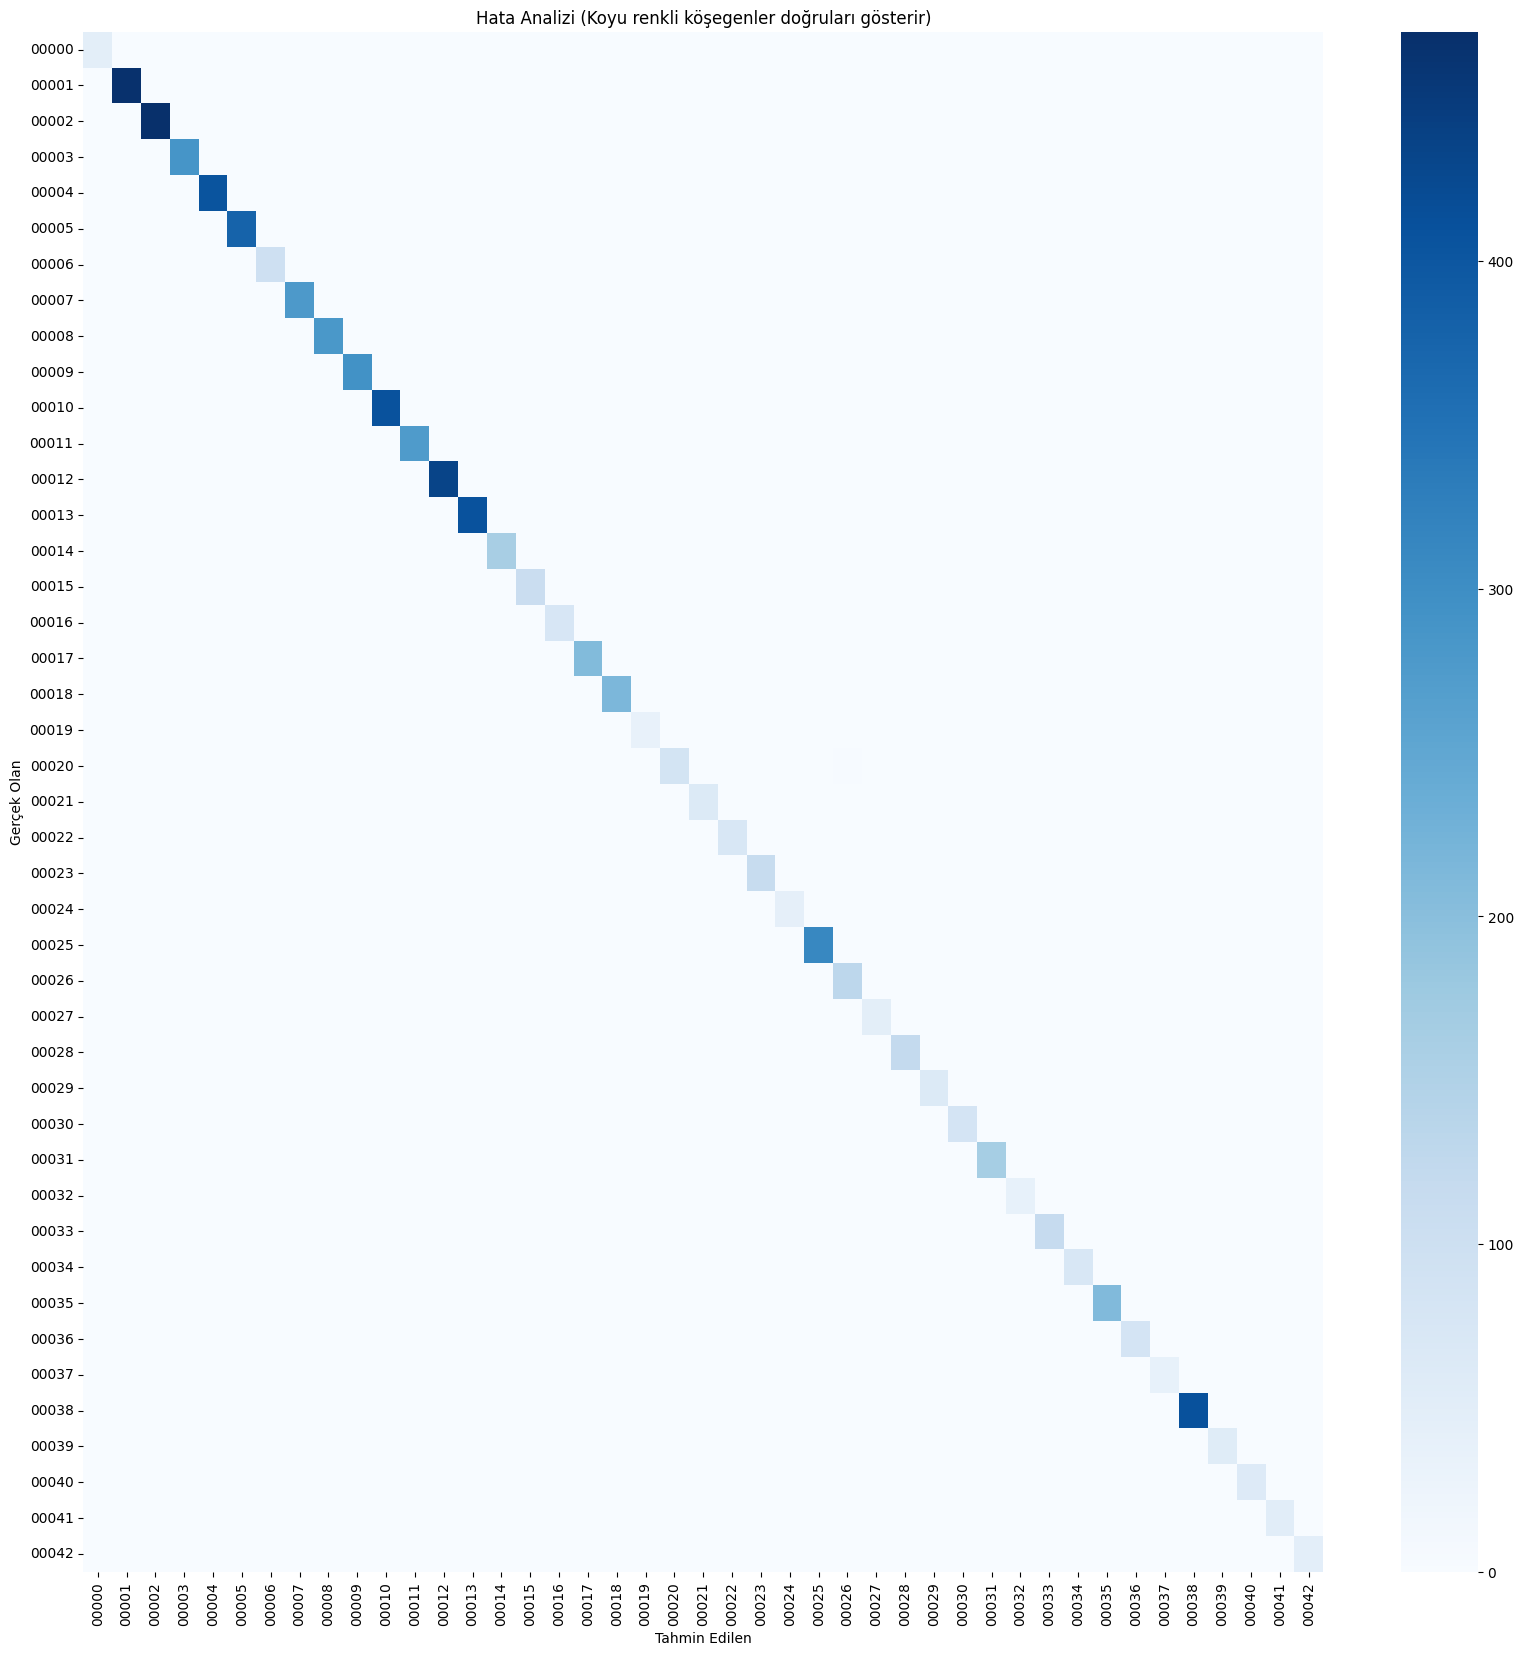

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

# 1. Gerçek Etiketleri ve Tahminleri Toplayalım
y_true = []
y_pred = []

print("Doğrulama seti üzerinde tahmin yapılıyor...")
# Doğrulama setindeki her bir grup (batch) için tahmin alıyoruz
for images, labels in val_ds:
    # Gerçek etiketleri listeye ekle
    y_true.extend(labels.numpy())

    # Modelin tahminlerini al
    predictions = model.predict(images, verbose=0)
    # En yüksek olasılığa sahip sınıfı seç (argmax)
    predicted_ids = np.argmax(predictions, axis=1)
    y_pred.extend(predicted_ids)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- A. GENEL DOĞRULUK (ACCURACY) ---
accuracy = np.mean(y_true == y_pred)
print(f"\n🏆 Modelin Genel Doğruluk Oranı: %{accuracy * 100:.2f}")

# --- B. SINIFLANDIRMA RAPORU (DETAYLI) ---
print("\n📋 Sınıf Bazlı Detaylı Rapor:")
# class_names listesi eğitim kodundan geliyor
print(classification_report(y_true, y_pred, target_names=class_names))

# --- C. KARMAŞIKLIK MATRİSİ (GÖRSEL HARİTA) ---
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_true, y_pred)

# Isı haritası çiz
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Olan')
plt.title('Hata Analizi (Koyu renkli köşegenler doğruları gösterir)')
plt.show()

In [8]:
import pandas as pd
from sklearn.metrics import accuracy_score
import os
import cv2
import numpy as np
from tqdm import tqdm
import glob

# --- 1. HARİCİ TEST VERİSİNİ İNDİR (Eğer yoksa) ---
if not os.path.exists('GTSRB_Final_Test_Images.zip'):
    print("Test verisi indiriliyor...")
    !wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
    !unzip -q GTSRB_Final_Test_Images.zip

    !wget -q https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip
    !unzip -q GTSRB_Final_Test_GT.zip
else:
    print("Test verisi zaten var, yolları kontrol ediyoruz...")

# --- 2. DOSYALARI OTOMATİK BUL (HATA ÇÖZÜMÜ BURADA) ---
# CSV dosyasını tüm klasörlerde ara ve bul
found_csv = glob.glob('**/GT-final_test.csv', recursive=True)

if len(found_csv) > 0:
    csv_path = found_csv[0]
    print(f"✅ CSV Dosyası Bulundu: {csv_path}")
else:
    # Bulamazsa tekrar indirip ana dizine çıkaralım
    print("⚠️ CSV bulunamadı, tekrar indiriliyor...")
    !wget -O GT-final_test.csv https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GT-final_test.csv
    csv_path = 'GT-final_test.csv'

# Resim klasörünü bul (Genelde GTSRB/Final_Test/Images olur)
found_img_dir = glob.glob('**/Final_Test/Images', recursive=True)
if len(found_img_dir) > 0:
    test_images_dir = found_img_dir[0]
    print(f"✅ Resim Klasörü Bulundu: {test_images_dir}")
else:
    print("❌ Resim klasörü bulunamadı! Lütfen 'GTSRB_Final_Test_Images.zip' dosyasının indiğinden emin olun.")
    test_images_dir = "HATA"

# --- 3. TESTİ BAŞLAT ---
if test_images_dir != "HATA":
    # CSV dosyasını oku
    df = pd.read_csv(csv_path, sep=';')

    print(f"\nToplam {len(df)} adet harici test resmi üzerinde model deneniyor...")

    y_true = []
    y_pred = []

    # Döngüyle tüm resimleri tek tek test et
    for i, row in tqdm(df.iterrows(), total=df.shape[0]):
        # Resim yolunu oluştur
        img_path = os.path.join(test_images_dir, row['Filename'])

        # Resmi oku (OpenCV .ppm dosyalarını okuyabilir, dönüştürmeye gerek yok)
        img = cv2.imread(img_path)

        if img is not None:
            # Boyutlandır (Modelimiz 128x128 bekliyor)
            img_resized = cv2.resize(img, (128, 128))

            # Modele sokulacak hale getir (Batch boyutu ekle)
            img_array = np.expand_dims(img_resized, axis=0)

            # Tahmin yap
            predictions = model.predict(img_array, verbose=0)
            predicted_class = np.argmax(predictions)

            # Listelere ekle
            y_true.append(row['ClassId'])
            y_pred.append(predicted_class)

    # --- 4. SONUÇLARI HESAPLA ---
    if len(y_true) > 0:
        real_accuracy = accuracy_score(y_true, y_pred)

        print("\n" + "="*40)
        print(f"🌍 HARİCİ TEST SONUCU (REAL WORLD TEST)")
        print("="*40)
        print(f"Test Edilen Resim Sayısı: {len(y_true)}")
        print(f"Doğru Bilinen Sayısı    : {np.sum(np.array(y_true) == np.array(y_pred))}")
        print(f"🏆 GERÇEK TEST BAŞARISI : %{real_accuracy * 100:.2f}")
        print("="*40)

        from sklearn.metrics import classification_report
        # Sınıf isimleri ingilizceye çevrildiği için hata vermemesi adına try-except
        try:
            print("\nDetaylı Rapor:")
            print(classification_report(y_true, y_pred))
        except:
            print("Sınıf isimleri uyuşmazlığı nedeniyle detaylı rapor basılamadı, ama yukarıdaki oran doğrudur.")
    else:
        print("Hiçbir resim test edilemedi. Dosya yollarını kontrol edin.")

Test verisi zaten var, yolları kontrol ediyoruz...
✅ CSV Dosyası Bulundu: GT-final_test.csv
✅ Resim Klasörü Bulundu: GTSRB/Final_Test/Images

Toplam 12630 adet harici test resmi üzerinde model deneniyor...


100%|██████████| 12630/12630 [16:54<00:00, 12.45it/s]


🌍 HARİCİ TEST SONUCU (REAL WORLD TEST)
Test Edilen Resim Sayısı: 12630
Doğru Bilinen Sayısı    : 9615
🏆 GERÇEK TEST BAŞARISI : %76.13

Detaylı Rapor:
              precision    recall  f1-score   support

           0       0.52      0.62      0.56        60
           1       0.95      0.99      0.97       720
           2       0.99      0.99      0.99       750
           3       0.85      0.96      0.90       450
           4       0.97      0.98      0.98       660
           5       0.85      0.97      0.91       630
           6       0.99      0.88      0.93       150
           7       0.70      0.94      0.80       450
           8       0.91      0.98      0.94       450
           9       0.94      0.95      0.95       480
          10       0.94      0.96      0.95       660
          11       0.90      0.96      0.93       420
          12       0.27      0.07      0.11       690
          13       0.91      0.99      0.95       720
          14       0.17      0.46     

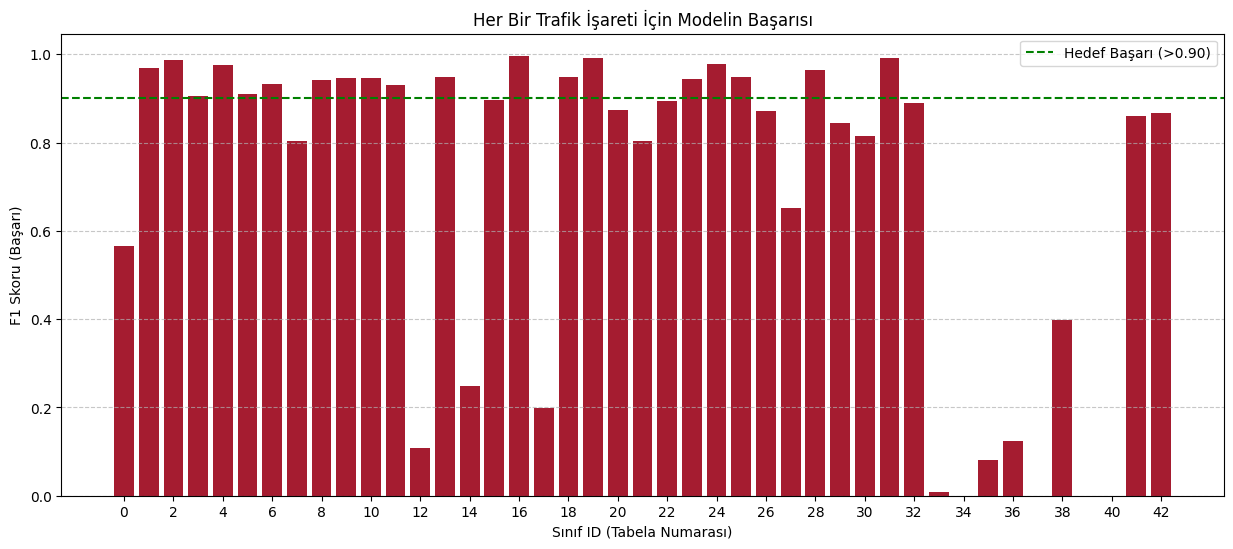

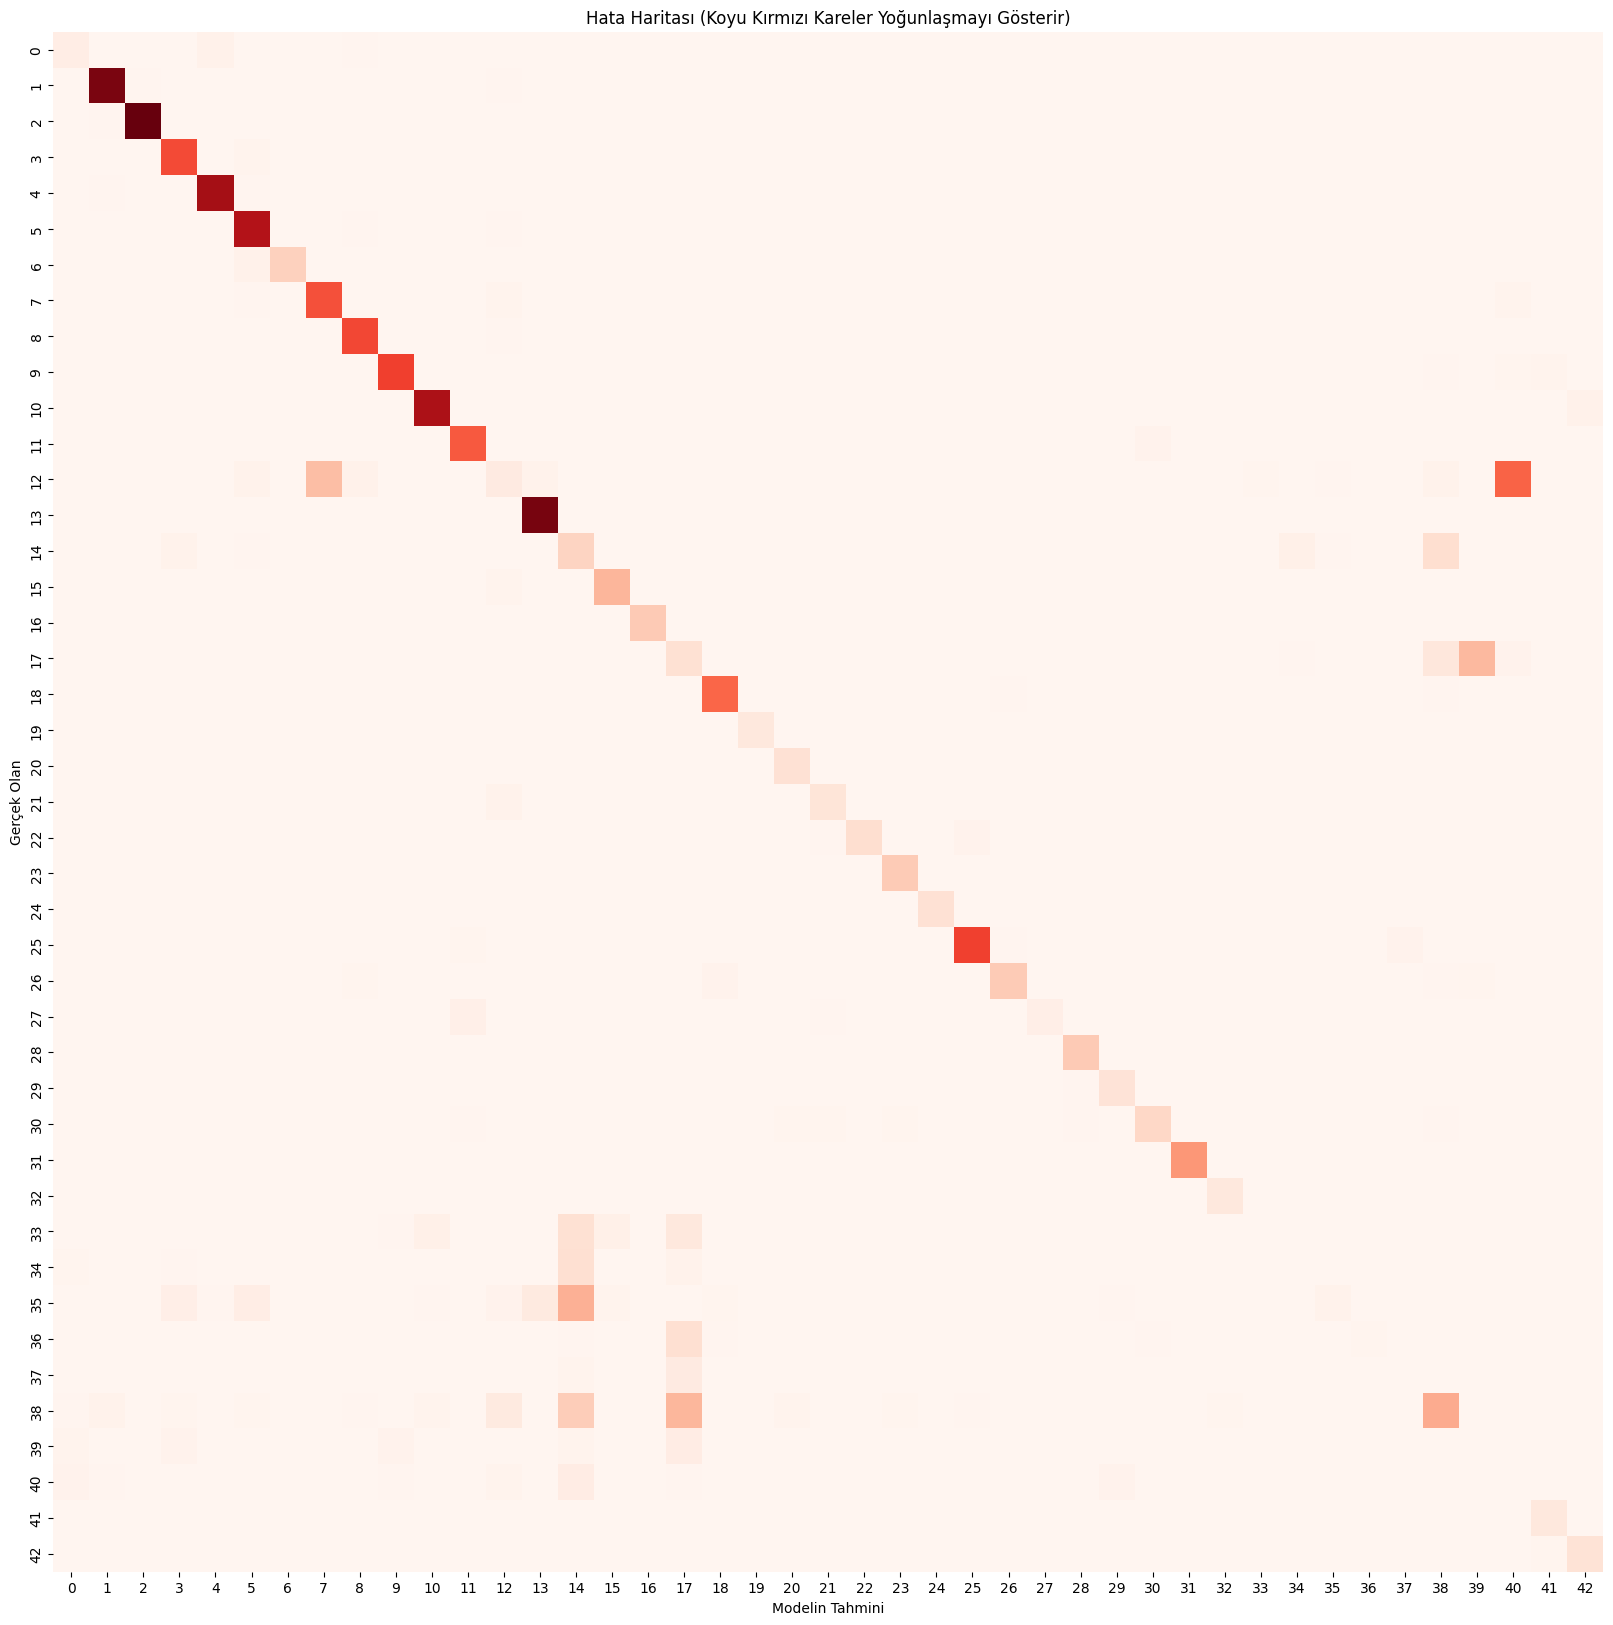

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np

# --- 1. SINIF BAZLI BAŞARI GRAFİĞİ (Bar Chart) ---
# F1 Skorunu her sınıf için hesaplayalım
f1_scores = f1_score(y_true, y_pred, average=None)

plt.figure(figsize=(15, 6))
plt.bar(range(43), f1_scores, color='#A51C30') # İYTE Kırmızısı
plt.xlabel('Sınıf ID (Tabela Numarası)')
plt.ylabel('F1 Skoru (Başarı)')
plt.title('Her Bir Trafik İşareti İçin Modelin Başarısı')
plt.xticks(range(0, 43, 2)) # X eksenini sıkıştırma
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Kritik not ekle
plt.axhline(y=0.9, color='green', linestyle='--', label='Hedef Başarı (>0.90)')
plt.legend()
plt.show()

# --- 2. KARMAŞIKLIK MATRİSİ (Confusion Matrix) ---
# Hangi tabela hangisiyle karışıyor?
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_true, y_pred)

# Görsellik: Sadece hataları vurgulamak için diyagonal (doğruları) silebiliriz
# Ama genel resmi görmek için normal bırakalım.
sns.heatmap(cm, annot=False, fmt='d', cmap='Reds', cbar=False)

plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Olan')
plt.title('Hata Haritası (Koyu Kırmızı Kareler Yoğunlaşmayı Gösterir)')
plt.show()